### Testing methods of Creating erorr Bars over 

1. First method is creating, 2dHistogram (binning all data). 
    - The averge over longitude - blue bars 
    - Calcuating error from the different latitude slices of the predetrmined bins 
    - Results: Gets a correct error but small sample size, only has 30 latitude slices
2. Second Method starts the same as first 
    - Then does a "slideing latitude slice window". 
    - this gives larger sample size of errrors to calcuate from 
3. Third attempt is resampling over all the data samples - very wrong
    - Resample with replacement all of the data samples, Calcuate averages from this 
4. Fourth attempt:
    - Resamples along one latitude, Breaks the lattitude row into 6-12 bins, then resamples the bins randomly. with the same length as the row. so resamples 6-12 bins. 


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
file = r"Data\Latlondata.csv"

data = pd.read_csv(file, header= None)

data = data.set_axis(["Longitude", "Latitude"], axis =1)
lon = data['Longitude']
lat = data['Latitude']

In [4]:
## first lets create bin sizes of 0.1 deg 
print(max(lon), min(lon))
print(max(lat),min(lat))

lat_range = np.arange(min(lat), max(lat), 0.1)
lon_range = np.arange(min(lon), max(lon), 0.1)

print(lat_range.shape)
print(lon_range.shape)

-160.66668 -163.74999999999997
7.750000000000057 4.500020000000063
(33,)
(31,)


In [5]:
def histogram2d(data, bins = 100):
    data = data.set_axis(["Longitude", "Latitude"], axis =1)
    lon = data['Longitude']
    lat = data['Latitude']

    gridded, lonedges, latedges  = np.histogram2d(lon,lat,bins = bins)
    gridded = gridded.T
    return gridded, lonedges, latedges

#### Method 1: Cacluating error Bars based off of variations in longitude. compaired each slice at diffent longitudes. 

In [6]:
Gridded, lonedges, latedges = histogram2d(data,bins = [lon_range,lat_range])
#Gridded.shape ##(lat,lon) = (32,30)


lat_mean = np.mean(Gridded,axis = 1)/3 ## convets to /year/0.1 deg
lat_mean[13] = np.mean(lat_mean)
errors = np.percentile(Gridded/3,95,axis = 1)
print(errors.shape)
error_bar = errors - lat_mean
error_bar[13] = np.mean(error_bar)
print (error_bar)

(32,)
[15.77222222 11.08333333  9.00555556 13.83888889 15.14444444 13.87777778
 11.33888889  8.87777778 14.02222222 10.02222222 15.98888889 11.59444444
 10.63333333 11.37376302 15.68333333  9.73333333  7.46111111  8.42777778
  9.34444444  8.59444444 14.15       14.56111111 12.17777778  8.46111111
 10.88333333  7.19444444  7.78333333  9.47777778 10.44444444  8.78888889
 14.82222222  8.67777778]


<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17800\2935622983.py:4: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")


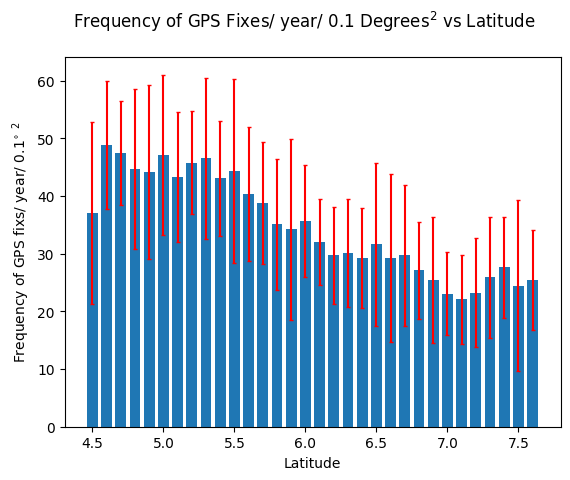

In [7]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle("Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings3.png")

In [ ]:
lonstart_list = np.random.rand(1000)*(lonedges[-1] - lonedges[0])+lonedges[0]
# window = np.array([lonstart[0], lonstart[0]+0.1])
# print(window)
#print(lonstart_list)

#### Method 2: Slideing Window - Trying to sample diffent longitudes with the same 

In [ ]:
##latedges, lonedges
Gridded_list = []
lonstart_list = np.random.rand(1000)*(lonedges[-1] - lonedges[0])+lonedges[0]
for i in range(1000):
    window = np.array([lonstart_list[i], lonstart_list[i]+0.1])
    #print(window)
    gridded, lonedges, latedges = histogram2d(data, bins = [window,lat_range])

    Gridded_list.append(gridded)

In [ ]:
gridded = np.array(Gridded_list)
print(gridded[:,:,0].shape)
gridded = gridded.reshape((1000,32))/3
print(gridded.shape)


In [ ]:
##calcuating error
errors = np.percentile(gridded,95,axis = 0)
error_bar = errors - lat_mean
error_bar[13:15] = np.mean(error_bar)
print (error_bar)
Gridded, lonedges, latedges = histogram2d(data,bins = [lon_range,lat_range])


lat_mean = np.mean(Gridded,axis = 1)/3 ## convets to /year/0.1 deg
lat_mean[13:15] = np.mean(lat_mean)

In [ ]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel(r"Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle(r"Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings4.png")

#### MEthod 3: Resampling over the whole domain

In [ ]:
total_num = data.shape[0]

Gridded_list = []
for n in range(1000):
    sample  = data.sample(n = total_num, replace = True)

    gridded, lonedges, latedges = histogram2d(sample, bins = [lon_range,lat_range])

    Gridded_list.append(gridded)

In [ ]:
print(latedges)

In [ ]:
Stacked = np.stack(Gridded_list, axis = 0)

mean_2d = np.mean(Stacked, axis= 0)
print(mean_2d.shape)

lat_mean = np.mean(mean_2d, axis = 1) ##Mean value to be plotted.
lat_mean[13] = np.mean(lat_mean)

lat_mean = lat_mean/30/3 ## averages over 0.1 degree in latitude. and per year 


##calcuating error
x = np.mean(Stacked, axis = 2)/30/3
print(x.shape)
errors = np.percentile(x,95,axis = 0)
error_bar = errors - lat_mean
error_bar[13] = np.mean(error_bar)
print (error_bar)

In [ ]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle("Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings2.png")

#### Method 4 

In [9]:
Binned_data, lonedges, latedges  = histogram2d(data, bins = [lon_range,lat_range])

print(Binned_data.shape)
mean_array = []
np.random.seed(50)
for n in range(1000):
    Randidex  = np.random.randint(0,30,30)
    #print(Randidex)
    selected_bins = []
    for i in Randidex:
        selected_bins.append(Binned_data[:,i])


    selected_bins = np.array(selected_bins)
    #print(selected_bins)
    mean_array.append(np.mean(selected_bins, axis = 0))

(32, 30)


In [10]:
mean_array = np.array(mean_array)
print(mean_array.shape)
errors = np.percentile(mean_array,95,axis = 0)/3
print(errors.shape)
lat_mean2 = np.mean(Binned_data,axis =1)/3 ##this is non bootstrapping data 
lat_mean = np.mean(mean_array,axis = 0)/3
#print(lat_mean)
#print(lat_mean2)
error_bar = errors - lat_mean
#error_bar[13] = np.mean(error_bar)
error_bar[13] = np.mean(error_bar)
lat_mean[13] = np.mean(lat_mean)
np.mean(lat_mean)


(1000, 32)
(32,)


np.float64(34.76751300998265)

In [17]:
Mean_dfads = np.mean(lat_mean) ## dFADs/year/0.1^2
Mean_dfads*8.905/24/365#/11.1/11.1*25*25 




np.float64(0.035343002665969805)

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\czerfass\AppData\Local\Temp\4\ipykernel_16520\719841503.py:4: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")


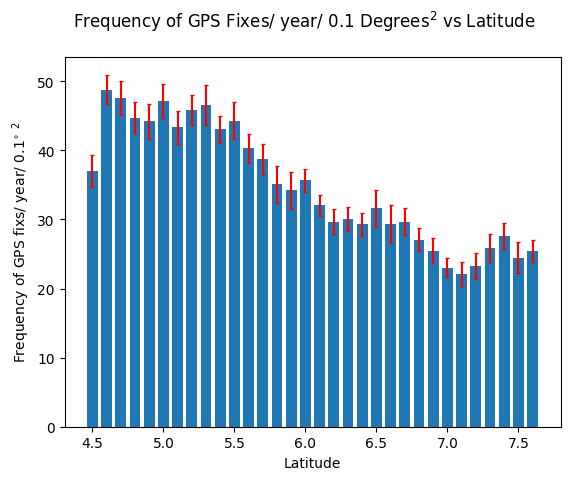

In [ ]:
fig, ax = plt.subplots()
ax.bar(latedges[:-1], lat_mean, width = 0.075, yerr = error_bar, ecolor = "r", capsize = 1.5)
ax.set_xlabel("Latitude")
ax.set_ylabel("Frequency of GPS fixs/ year/ 0.1$^{\circ}$ $^{2}$")
fig.suptitle("Frequency of GPS Fixes/ year/ 0.1 Degrees$^{2}$ vs Latitude")
#fig.savefig(r"C:\FATE\Figures\Frequency of GPS pings6.png")